In [1]:
!pip install pandas numpy matplotlib seaborn missingno


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# 01_data_understanding.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno



In [6]:
# Load data
df = pd.read_csv('../data/student_performance_data.csv')
df


,study_hours_per_week,attendance_percentage,homework_completion,parental_involvement,sleep_hours,previous_gpa,math_score,reading_score,performance_group
0,NaN,NaN,78.6,4.8,5.2,2.8,60.0,79.3,Average
1,7.0,83.3,73.1,10.0,7.5,3.2,66.8,79.4,Average
2,3.7,65.9,50.6,NaN,6.7,1.5,55.2,51.4,Low
3,14.8,93.5,NaN,8.9,6.7,3.8,88.5,91.8,High
4,12.6,92.5,93.6,9.5,7.5,3.7,92.3,85.2,High
...,...,...,...,...,...,...,...,...,...
295,7.1,NaN,68.8,6.1,4.4,1.7,55.3,55.6,Low
296,18.2,98.3,NaN,10.0,7.0,3.5,82.9,76.1,High
297,20.6,NaN,98.4,10.0,7.0,3.3,87.4,89.8,High
298,4.8,64.7,NaN,1.0,4.2,1.9,70.1,52.5,Low


In [7]:
# 1. Basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())



Shape: (300, 9)

Columns: ['study_hours_per_week', 'attendance_percentage', 'homework_completion', 'parental_involvement', 'sleep_hours', 'previous_gpa', 'math_score', 'reading_score', 'performance_group']

Data Types:
study_hours_per_week     float64
attendance_percentage    float64
homework_completion      float64
parental_involvement     float64
sleep_hours              float64
previous_gpa             float64
math_score               float64
reading_score            float64
performance_group         object
dtype: object

Missing Values:
study_hours_per_week     35
attendance_percentage    43
homework_completion      43
parental_involvement     37
sleep_hours              39
previous_gpa             43
math_score                0
reading_score             0
performance_group         0
dtype: int64


In [8]:
# 2. Statistical summary
print("\nDescriptive Statistics:")
print(df.describe())




Descriptive Statistics:
       study_hours_per_week  attendance_percentage  homework_completion  \
count            265.000000             257.000000           257.000000   
mean              12.768679              82.918677            76.820233   
std                7.868587              17.556468            20.384796   
min              -12.400000             -96.100000             5.000000   
25%                7.000000              75.100000            62.600000   
50%               12.600000              87.600000            82.100000   
75%               18.200000              94.200000            93.700000   
max               40.000000             120.000000           100.000000   

       parental_involvement  sleep_hours  previous_gpa  math_score  \
count            263.000000   261.000000    257.000000  300.000000   
mean               6.467681     6.998467      2.813619   72.717333   
std                2.574905     1.685229      0.958519   16.016855   
min                

In [9]:
# 3. Check for invalid values
print("\n--- Invalid Value Check ---")
if 'study_hours' in df.columns:
    print("Negative study hours:", (df['study_hours'] < 0).sum())
if 'attendance' in df.columns:
    print("Attendance >100%:", (df['attendance'] > 100).sum())
if 'gpa' in df.columns:
    print("Negative GPA:", (df['gpa'] < 0).sum())
if 'sleep_hours' in df.columns:
    print("Negative sleep:", (df['sleep_hours'] < 0).sum())




--- Invalid Value Check ---
Negative sleep: 1


FileNotFoundError: [Errno 2] No such file or directory: '../report/figures/histograms.png'

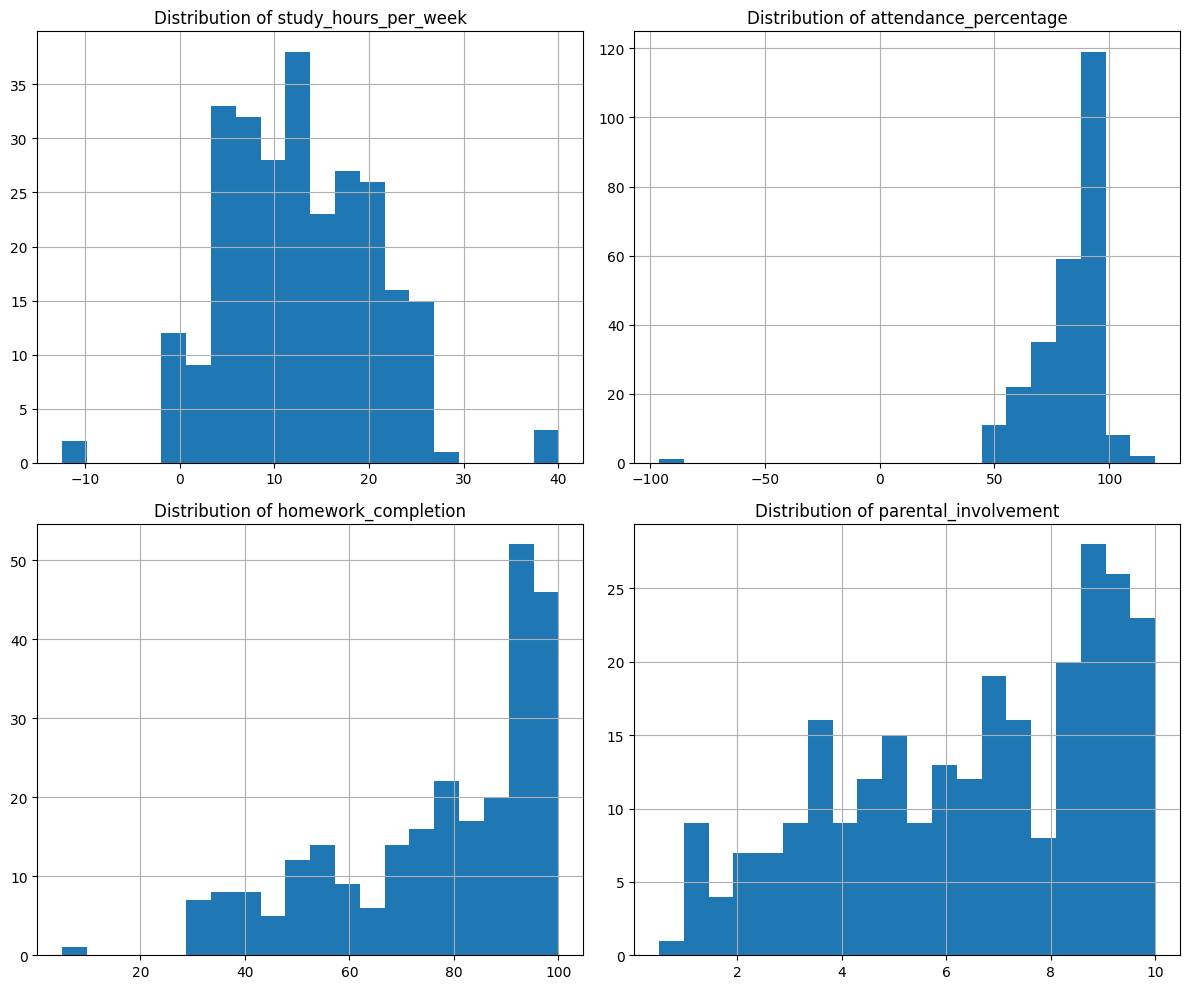

In [10]:
# 4. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Histograms
numeric_cols = df.select_dtypes(include=[np.number]).columns[:4]
for i, col in enumerate(numeric_cols):
    row, col_idx = i//2, i%2
    df[col].hist(ax=axes[row, col_idx], bins=20)
    axes[row, col_idx].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.savefig('../report/figures/histograms.png')
plt.show()



FileNotFoundError: [Errno 2] No such file or directory: '../reports/figures/boxplots.png'

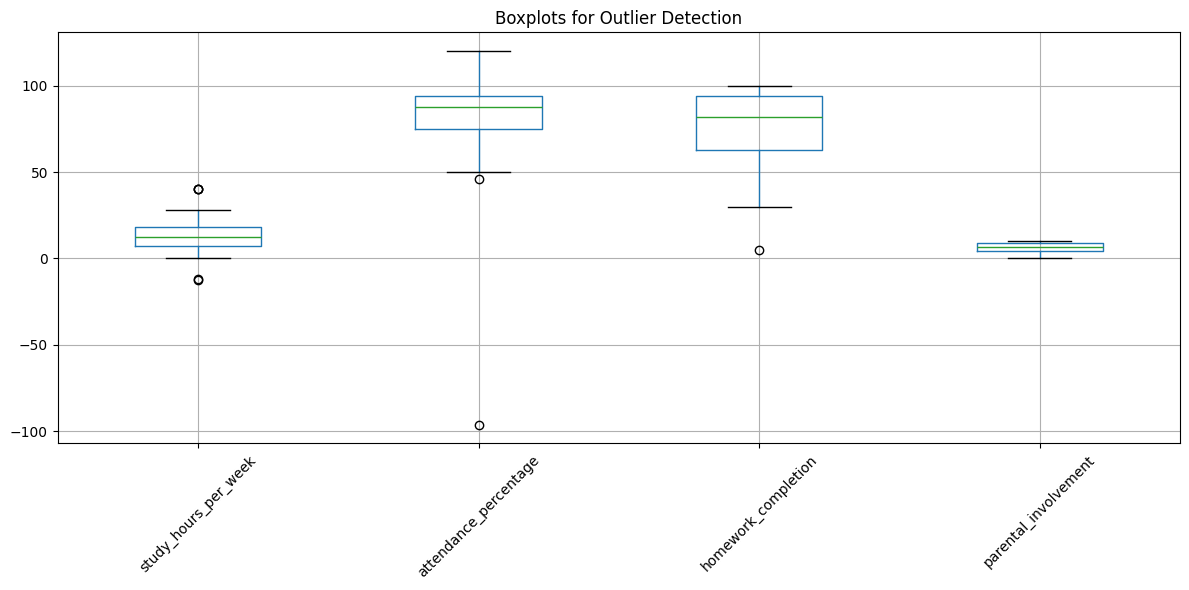

In [11]:
# Boxplots for outliers
plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot()
plt.title('Boxplots for Outlier Detection')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/boxplots.png')
plt.show()



C:\Users\Henok\AppData\Local\Temp\ipykernel_10260\1596451191.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


FileNotFoundError: [Errno 2] No such file or directory: '../report/figures/missing_values.png'

<Figure size 1000x600 with 0 Axes>

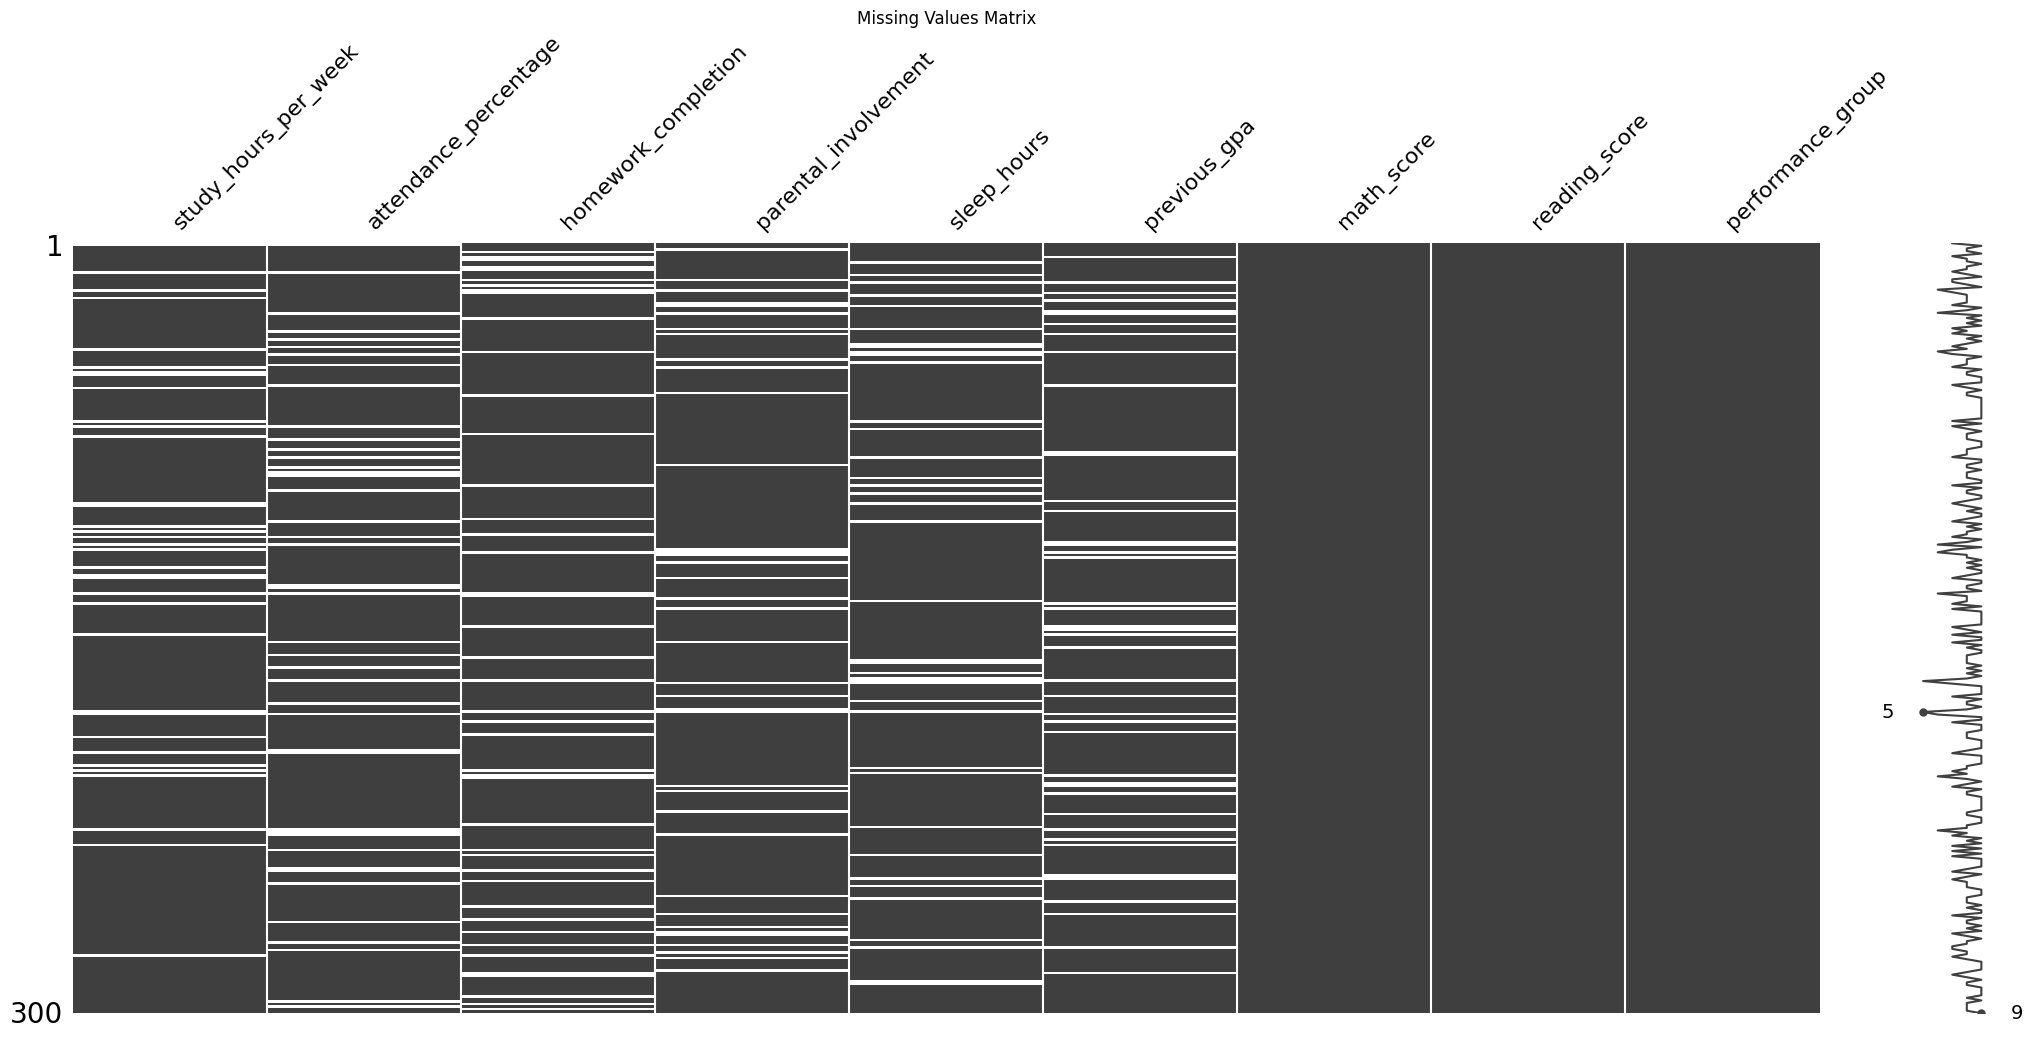

In [15]:
# Missing values heatmap
plt.figure(figsize=(10, 6))
msno.matrix(df)
plt.title('Missing Values Matrix')
plt.tight_layout()
plt.savefig('../report/figures/missing_values.png')
plt.show()



In [14]:
# 5. Save summary report
with open('../report/data_summary.txt', 'w') as f:
    f.write(f"DATA UNDERSTANDING SUMMARY\n")
    f.write(f"{'='*50}\n")
    f.write(f"Shape: {df.shape}\n")
    f.write(f"Missing Values:\n{df.isnull().sum()}\n")
    f.write(f"\nInvalid Values:\n")
    if 'study_hours' in df.columns:
        f.write(f"Negative study_hours: {(df['study_hours'] < 0).sum()}\n")
    if 'attendance' in df.columns:
        f.write(f"Attendance >100: {(df['attendance'] > 100).sum()}\n")